In [11]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

DATA_DIR = "../../data/OverlapCoefficient"
OUT_DIR = "../../plot/OverlapCoefficient"
os.makedirs(OUT_DIR, exist_ok=True)

REAL_CSV = os.path.join(DATA_DIR, "RealDistribution_sameCN.csv")
BG_CSV   = os.path.join(DATA_DIR, "BackgroundDistribution_randomCN.csv")
TTEST_CSV = os.path.join(DATA_DIR, "TTest_Results.csv")

BG_LABEL = "0-distribution"

def cn_sort_key(cn_name):
    s = str(cn_name).strip()
    digits = "".join(ch for ch in s if ch.isdigit())
    return int(digits) if digits else 10**9

读取数据

In [12]:
real_df = pd.read_csv(REAL_CSV)
bg_df = pd.read_csv(BG_CSV)
ttest_df = pd.read_csv(TTEST_CSV)

real_df["CN"] = real_df["CN"].astype(str).str.strip()
real_df["OverlapCoefficient"] = pd.to_numeric(real_df["OverlapCoefficient"], errors="coerce")
bg_df["OverlapCoefficient"] = pd.to_numeric(bg_df["OverlapCoefficient"], errors="coerce")

real_df = real_df.dropna(subset=["CN", "OverlapCoefficient"])
bg_df = bg_df.dropna(subset=["OverlapCoefficient"])

cn_levels = sorted(real_df["CN"].unique(), key=cn_sort_key)
cn_levels

['TCN1',
 'TCN2',
 'TCN3',
 'TCN4',
 'TCN5',
 'TCN6',
 'TCN7',
 'TCN8',
 'TCN9',
 'TCN10']

violin_plot

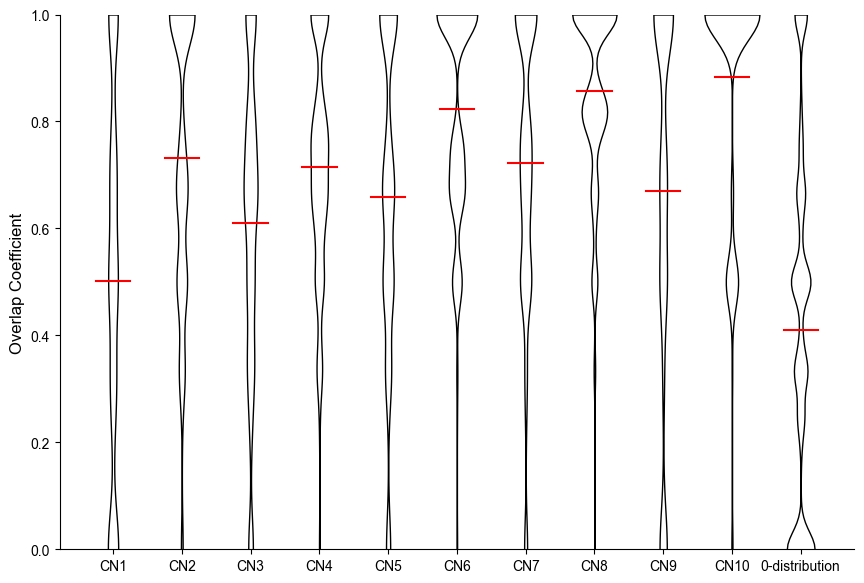

In [13]:
plot_real = real_df[["CN", "OverlapCoefficient"]].copy()
plot_real = plot_real.rename(columns={"CN": "Group"})

plot_bg = pd.DataFrame({
    "Group": [BG_LABEL] * len(bg_df),
    "OverlapCoefficient": bg_df["OverlapCoefficient"].values
})

plot_df = pd.concat([plot_real, plot_bg], axis=0, ignore_index=True)
order = cn_levels + [BG_LABEL]

fig, ax = plt.subplots(figsize=(8.8, 6))

sns.violinplot(
    data=plot_df,
    x="Group",
    y="OverlapCoefficient",
    order=order,
    inner=None,
    cut=0,
    color="white",
    linewidth=1,
    ax=ax
)

for poly in ax.collections:
    try:
        poly.set_edgecolor("black")
        poly.set_facecolor("white")
    except Exception:
        pass

means = plot_df.groupby("Group", observed=False)["OverlapCoefficient"].mean().reindex(order)

for i, g in enumerate(order):
    if pd.notna(means[g]):
        ax.plot([i - 0.25, i + 0.25], [means[g], means[g]], color="red", lw=1.5)

xticklabels = [x.replace("TCN", "CN") if x != BG_LABEL else BG_LABEL for x in order]
ax.set_xticks(range(len(order)))
ax.set_xticklabels(xticklabels)

ax.set_xlabel("")
ax.set_ylabel("Overlap Coefficient")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "OC_violin_with_0_distribution.pdf"), dpi=1200)
plt.show()

mean-violin_plot

In [ ]:
pooled_df = pd.concat([
    pd.DataFrame({
        "Group": ["All CNs"] * len(real_df),
        "OverlapCoefficient": real_df["OverlapCoefficient"].values
    }),
    pd.DataFrame({
        "Group": [BG_LABEL] * len(bg_df),
        "OverlapCoefficient": bg_df["OverlapCoefficient"].values
    })
], axis=0, ignore_index=True)

order = ["All CNs", BG_LABEL]

fig, ax = plt.subplots(figsize=(5.4, 6))

sns.violinplot(
    data=pooled_df,
    x="Group",
    y="OverlapCoefficient",
    order=order,
    inner=None,
    cut=0,
    color="white",
    linewidth=1,
    ax=ax
)

for poly in ax.collections:
    try:
        poly.set_edgecolor("black")
        poly.set_facecolor("white")
    except Exception:
        pass

means = pooled_df.groupby("Group", observed=False)["OverlapCoefficient"].mean().reindex(order)

for i, g in enumerate(order):
    if pd.notna(means[g]):
        ax.plot([i - 0.25, i + 0.25], [means[g], means[g]], color="red", lw=1.8)
        ax.text(i + 0.28, means[g], f"{means[g]:.3f}", color="red", va="center", fontsize=10)

ax.set_xlabel("")
ax.set_ylabel("Overlap Coefficient")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "OC_mean_violin_real_vs_0_distribution.pdf"), dpi=1200)
plt.show()

real vs background plot

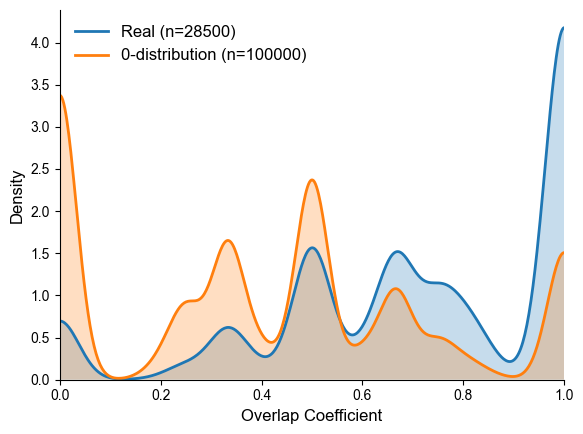

In [14]:
XMIN, XMAX = 0.0, 1.0
N_GRID = 500

def kde_curve(values, x_grid):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.zeros_like(x_grid)

    if np.allclose(values, values[0]):
        y = np.zeros_like(x_grid)
        idx = np.argmin(np.abs(x_grid - values[0]))
        y[idx] = 1.0
        kernel = np.array([0.2, 0.6, 0.2])
        y = np.convolve(y, kernel, mode="same")
        area = np.trapz(y, x_grid)
        if area > 0:
            y = y / area
        return y

    try:
        kde = gaussian_kde(values)
        return kde(x_grid)
    except Exception:
        hist, edges = np.histogram(values, bins=30, range=(XMIN, XMAX), density=True)
        mids = (edges[:-1] + edges[1:]) / 2
        return np.interp(x_grid, mids, hist, left=0, right=0)

real_vals = real_df["OverlapCoefficient"].values
bg_vals = bg_df["OverlapCoefficient"].values

x_grid = np.linspace(XMIN, XMAX, N_GRID)
y_real = kde_curve(real_vals, x_grid)
y_bg   = kde_curve(bg_vals, x_grid)

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(x_grid, y_real, linewidth=2.0, label=f"Real (n={len(real_vals)})")
ax.plot(x_grid, y_bg, linewidth=2.0, label=f"0-distribution (n={len(bg_vals)})")

ax.fill_between(x_grid, 0, y_real, alpha=0.25)
ax.fill_between(x_grid, 0, y_bg, alpha=0.25)

ax.set_xlabel("Overlap Coefficient")
ax.set_ylabel("Density")
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(bottom=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Overall_Real_vs_0_distribution_KDE.pdf"), dpi=1200)
plt.show()